# Faster FIxLIP approximation

We compare the new ProxySHAP approximation algorithm, which improves the faithfulness in low budget regimes, against the original one.

This example requires the updated `fixlip_faster` environment installed via `conda env create -f env_faster.yml`.

In [1]:
import os
from pathlib import Path
import torch
torch.set_float32_matmul_precision("high")
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import shapiq 
import src

### load model

In [2]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
model.to('cuda')
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


### load data

In [3]:
input_text = "black dog next to a yellow hydrant"
input_image = Image.open("assets/dog_and_hydrant.png")

### define game

In [4]:
game = src.game_huggingface.VisionLanguageGame(
    model=model,
    processor=processor,
    input_image=input_image,
    input_text=input_text,
    batch_size=64
)
n_players_image = game.n_players_image
n_players_text = game.n_players_text

### define approximators

In [5]:
fixlip_original = src.fixlip.FIxLIP(n_players_image=n_players_image, n_players_text=n_players_text, random_state=0, approximation_type="original")
fixlip_proxyshap = src.fixlip.FIxLIP(n_players_image=n_players_image, n_players_text=n_players_text, random_state=0, approximation_type="proxyshap")

### compute explanations

Original implementation

In [6]:
src.utils.set_seed(0)
iv_original = fixlip_original.approximate(game, budget=2**11)

New implementation

In [7]:
src.utils.set_seed(0)
iv_proxyshap = fixlip_proxyshap.approximate(game, budget=2**11)

### compare explanations against a higher budget one

In [8]:
src.utils.set_seed(0)
iv_ground_truth = fixlip_original.approximate(game, budget=2**16)

In [9]:
def mse(a, b):
    return np.mean(np.abs(a - b))
print(f'Approximation error of original: {mse(iv_original.values, iv_ground_truth.values):.6f}')
print(f'Approximation error of proxyshap: {mse(iv_proxyshap.values, iv_ground_truth.values):.6f}')

Approximation error of original: 0.187770
Approximation error of proxyshap: 0.072077


### save explanation

In [ ]:
# iv_proxyshap.save(Path(os.path.join("results", "dog_and_hydrant_fixlip.json")))

### visualize explanation

In [ ]:
# iv_proxyshap = shapiq.InteractionValues.load("results/dog_and_hydrant_fixlip.json")
print(iv_proxyshap)

InteractionValues(
    index=FBII, max_order=2, min_order=0, estimated=False, estimation_budget=2048,
    n_players=57, baseline_value=22.867069244384766,
    Top 10 interactions:
        (): 22.867069244384766
        (54,): 2.74532941208102
        (55, 56): 1.5485660603408178
        (33, 55): 1.22496073700313
        (29, 50): 1.1202094800373743
        (28, 50): 1.119903527183851
        (49, 50): -1.0091619371669367
        (49,): -1.0808522953673219
        (50,): -1.4557036522698965
        (55,): -3.6111042931756856
)


In [12]:
def denormalize(img, mean, std):
    return img * torch.tensor(std).view(3, 1, 1) + torch.tensor(mean).view(3, 1, 1)
image_mean = (0.48145466, 0.4578275, 0.40821073)
image_std = (0.26862954, 0.26130258, 0.27577711)

In [13]:
text_tokens = game.inputs.tokens()
text_tokens = text_tokens[1:-1]
text_tokens = [token.replace('</w>', '') for token in text_tokens]
assert len(text_tokens) == game.n_players_text
players_text = list(range(game.n_players_image, game.n_players))
assert game.n_players == iv_proxyshap.n_players == max(players_text) + 1
input_image_processed = game.inputs['pixel_values'].squeeze(0)
input_image_denormalized = src.utils.denormalize(
    input_image_processed, 
    game.processor.image_processor.image_mean, 
    game.processor.image_processor.image_std
).permute(1, 2, 0).numpy()

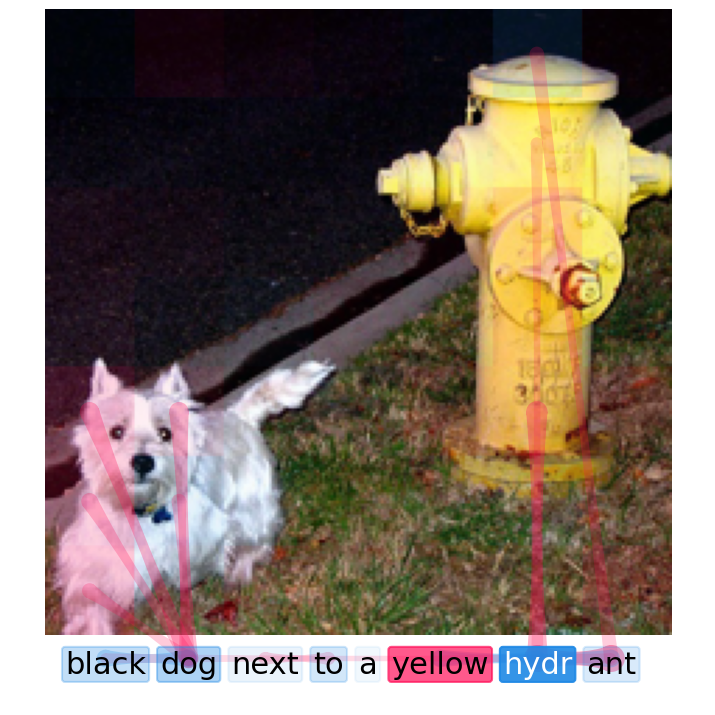

In [14]:
src.plot.plot_image_and_text_together(
    img=input_image_denormalized,
    text=text_tokens,
    image_players=list(range(n_players_image)),
    iv=iv_proxyshap,
    plot_interactions=True,
    top_k=14,
    normalize_jointly=True,
    figsize=(7, 7),
    fontsize=22,
    margin=0.3,
    color_text=True,
    plot_heatmap=True,
    show=False,
    max_value=4
)
plt.tight_layout(pad=0.15)
# plt.savefig("dog_and_hydrant_fixlip.pdf")